<a href="https://www.kaggle.com/code/lalit7881/global-country-indices-analysis-eda?scriptVersionId=338114404" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv")

In [3]:
df.head()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,Afghanistan,2000,Asia,4,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,4,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,4,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,4,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,4,194,210,197,214,183,185,216,172,214,217,212


In [4]:
df.tail()

,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
5854,Zimbabwe,2022,Africa,3,167,173,180,165,200,164,182,208,162,163,186
5855,Zimbabwe,2023,Africa,3,167,173,182,171,200,163,183,209,162,162,186
5856,Zimbabwe,2024,Africa,3,168,173,180,170,200,163,183,210,162,163,187
5857,Zimbabwe,2025,Africa,3,170,173,180,170,200,163,183,210,162,162,186
5858,Zimbabwe,2026,Africa,3,167,173,180,170,200,163,183,210,162,162,187


In [5]:
df.isnull().sum()

Country                           0
Year                              0
Region                            0
Economic_Tier                     0
Happiness_Rank                    0
Global_Hunger_Rank                0
Human_Development_Rank            0
GDP_Per_Capita_Rank               0
Life_Expectancy_Rank              0
Corruption_Perception_Rank        0
Democracy_Rank                    0
Gini_Rank                         0
Press_Freedom_Rank                0
Global_Peace_Rank                 0
Environmental_Performance_Rank    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['Country', 'Year', 'Region', 'Economic_Tier', 'Happiness_Rank',
       'Global_Hunger_Rank', 'Human_Development_Rank', 'GDP_Per_Capita_Rank',
       'Life_Expectancy_Rank', 'Corruption_Perception_Rank', 'Democracy_Rank',
       'Gini_Rank', 'Press_Freedom_Rank', 'Global_Peace_Rank',
       'Environmental_Performance_Rank'],
      dtype='object')

In [8]:
df.dtypes

Country                           object
Year                               int64
Region                            object
Economic_Tier                      int64
Happiness_Rank                     int64
Global_Hunger_Rank                 int64
Human_Development_Rank             int64
GDP_Per_Capita_Rank                int64
Life_Expectancy_Rank               int64
Corruption_Perception_Rank         int64
Democracy_Rank                     int64
Gini_Rank                          int64
Press_Freedom_Rank                 int64
Global_Peace_Rank                  int64
Environmental_Performance_Rank     int64
dtype: object

In [9]:
df.shape

(5859, 15)

In [10]:
df.nunique()

Country                           217
Year                               27
Region                              5
Economic_Tier                       4
Happiness_Rank                    217
Global_Hunger_Rank                201
Human_Development_Rank            217
GDP_Per_Capita_Rank               217
Life_Expectancy_Rank              217
Corruption_Perception_Rank        217
Democracy_Rank                    217
Gini_Rank                         217
Press_Freedom_Rank                217
Global_Peace_Rank                 217
Environmental_Performance_Rank    217
dtype: int64

## EDA

       Country  Year Region  Economic_Tier  Happiness_Rank  \
0  Afghanistan  2000   Asia              4             195   
1  Afghanistan  2001   Asia              4             198   
2  Afghanistan  2002   Asia              4             196   
3  Afghanistan  2003   Asia              4             196   
4  Afghanistan  2004   Asia              4             194   

   Global_Hunger_Rank  Human_Development_Rank  GDP_Per_Capita_Rank  \
0                 208                     187                  212   
1                 207                     188                  215   
2                 208                     192                  213   
3                 207                     195                  214   
4                 210                     197                  214   

   Life_Expectancy_Rank  Corruption_Perception_Rank  Democracy_Rank  \
0                   186                         185             215   
1                   186                         185             

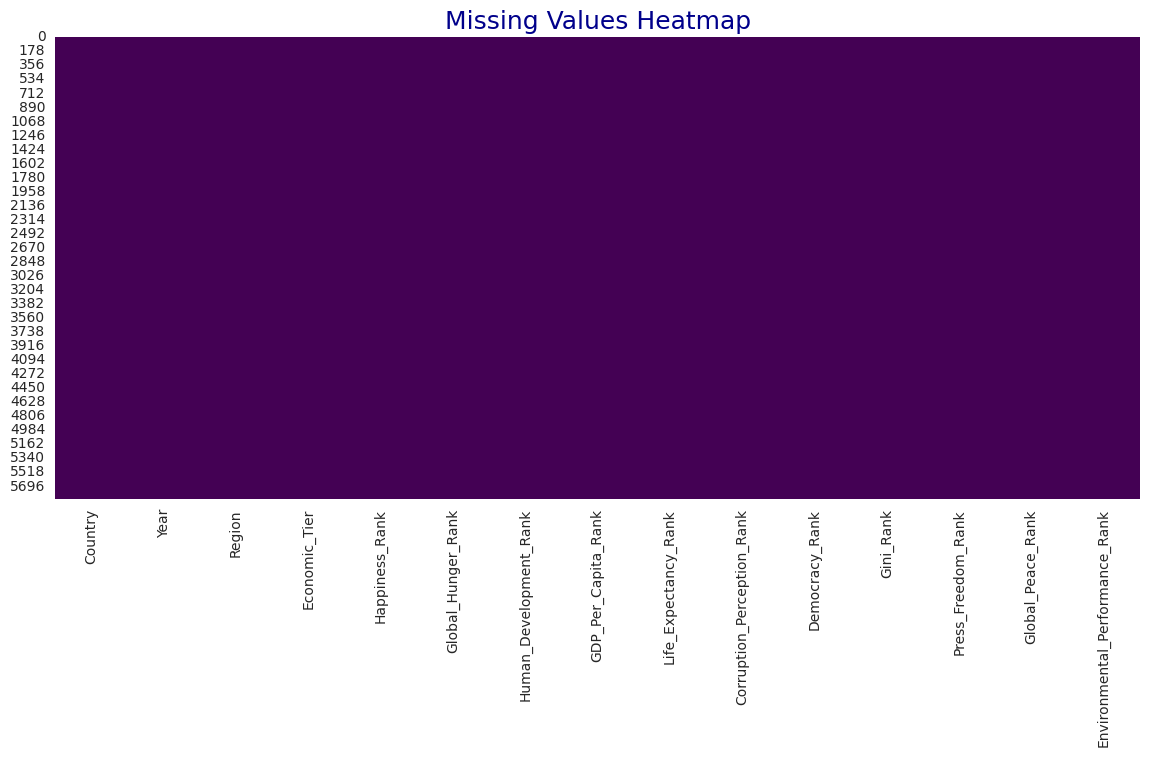

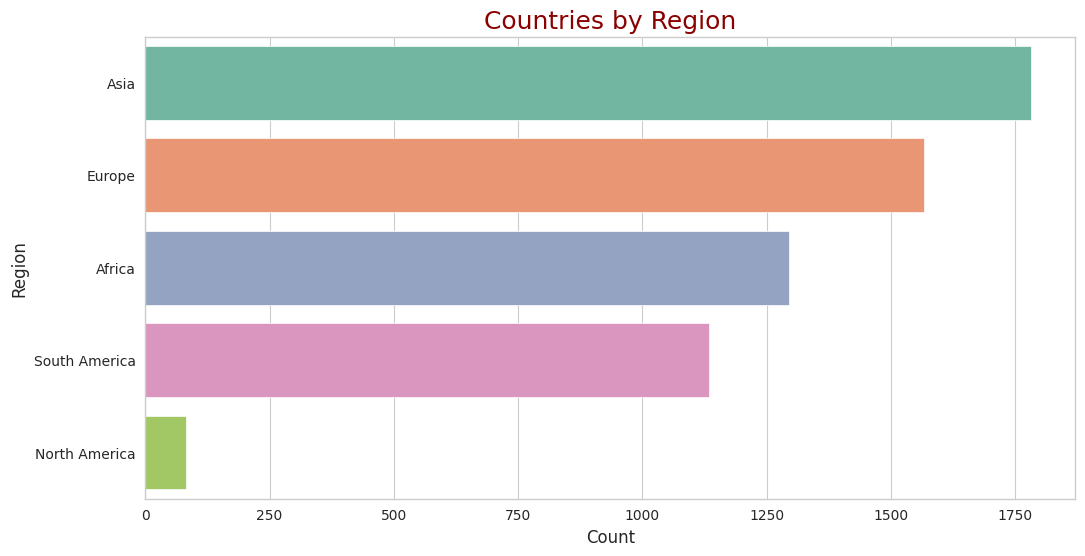

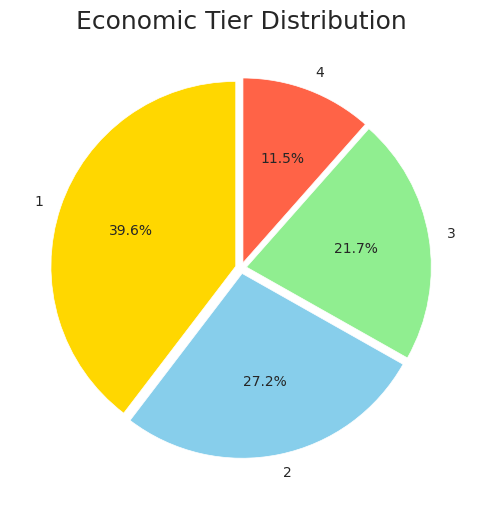

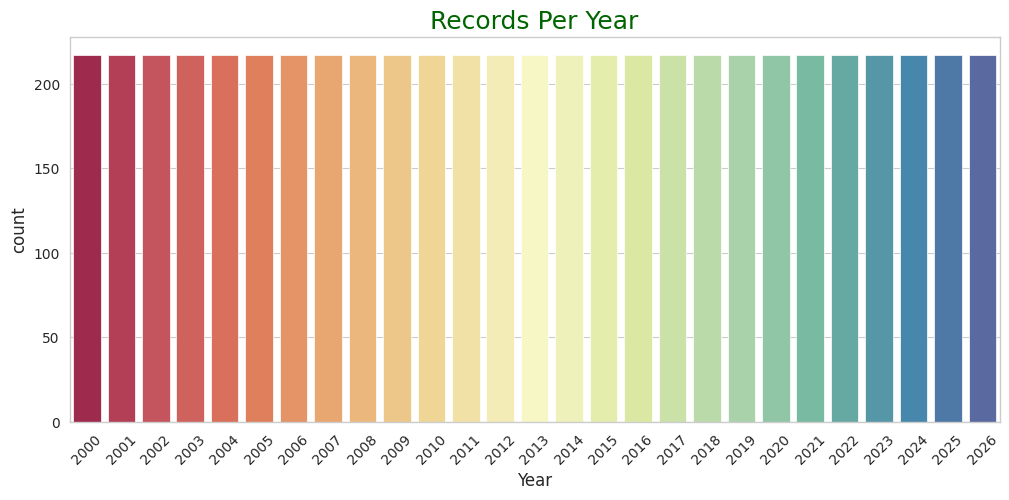

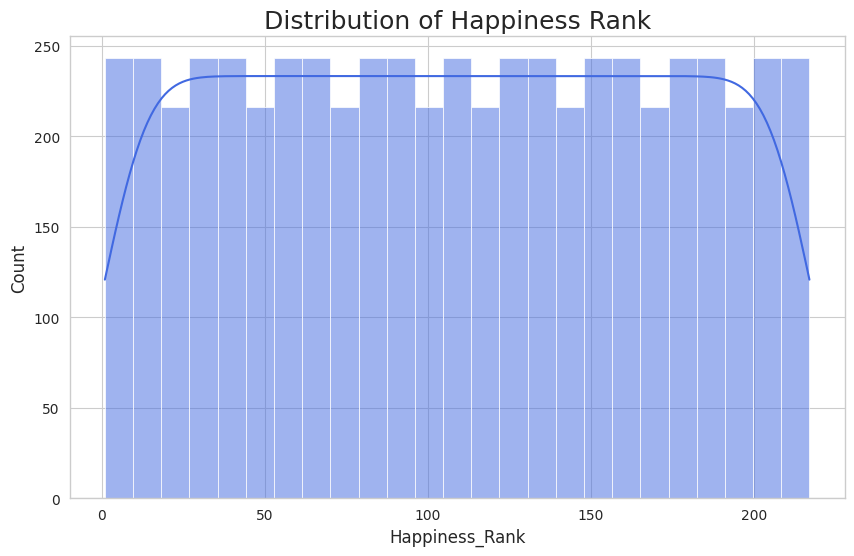

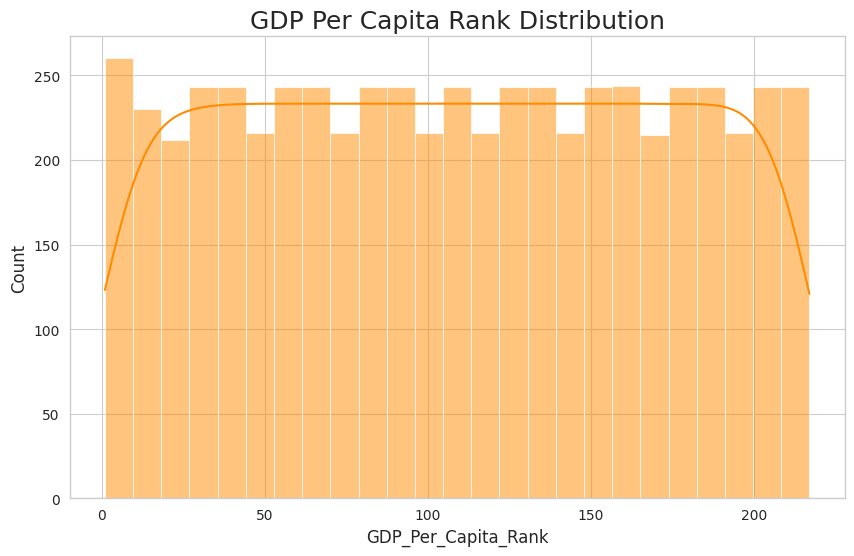

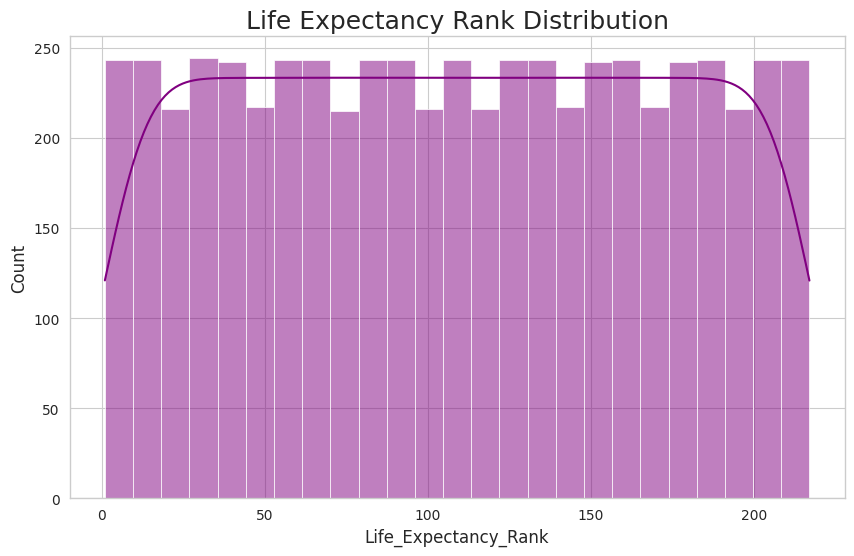

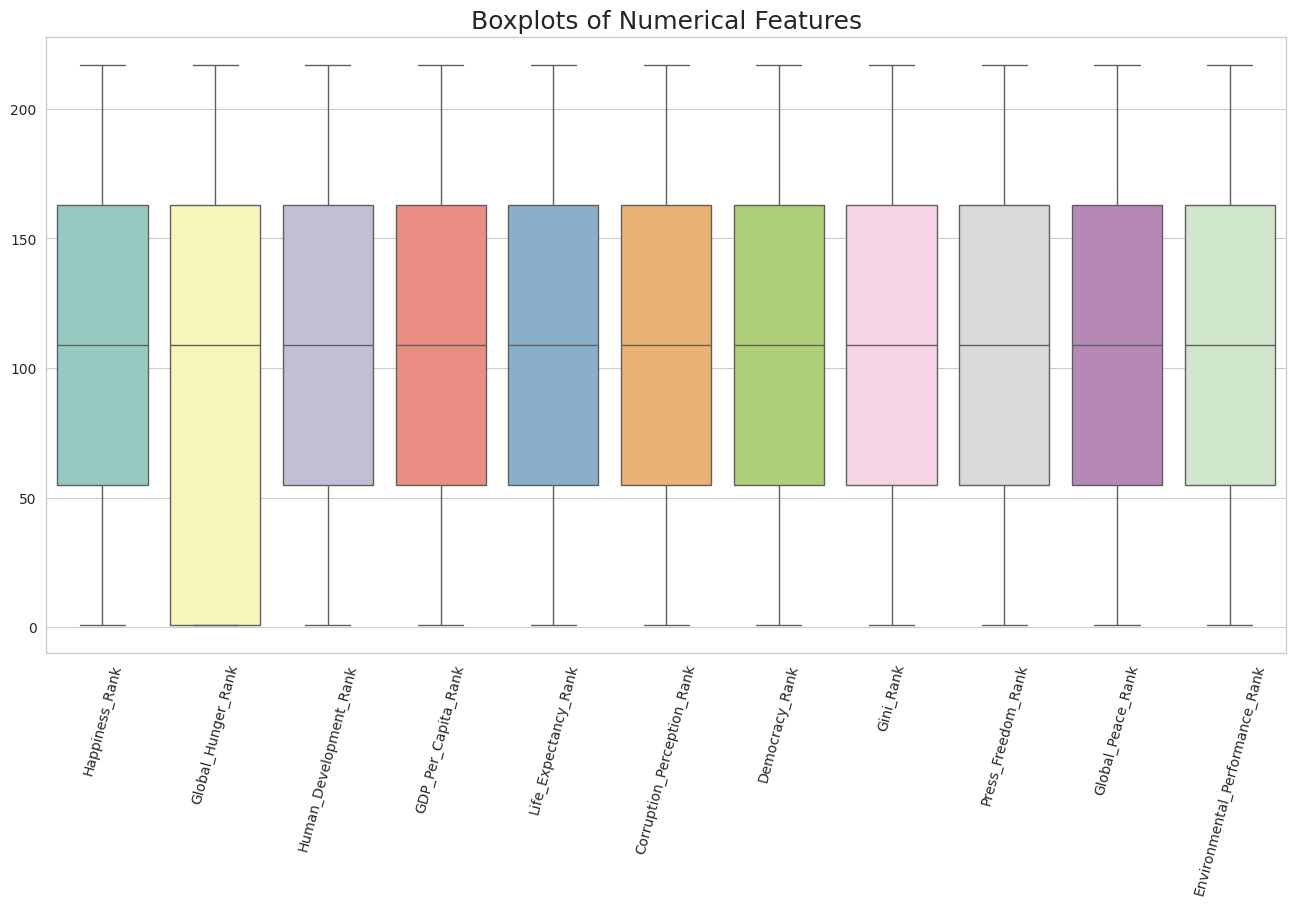

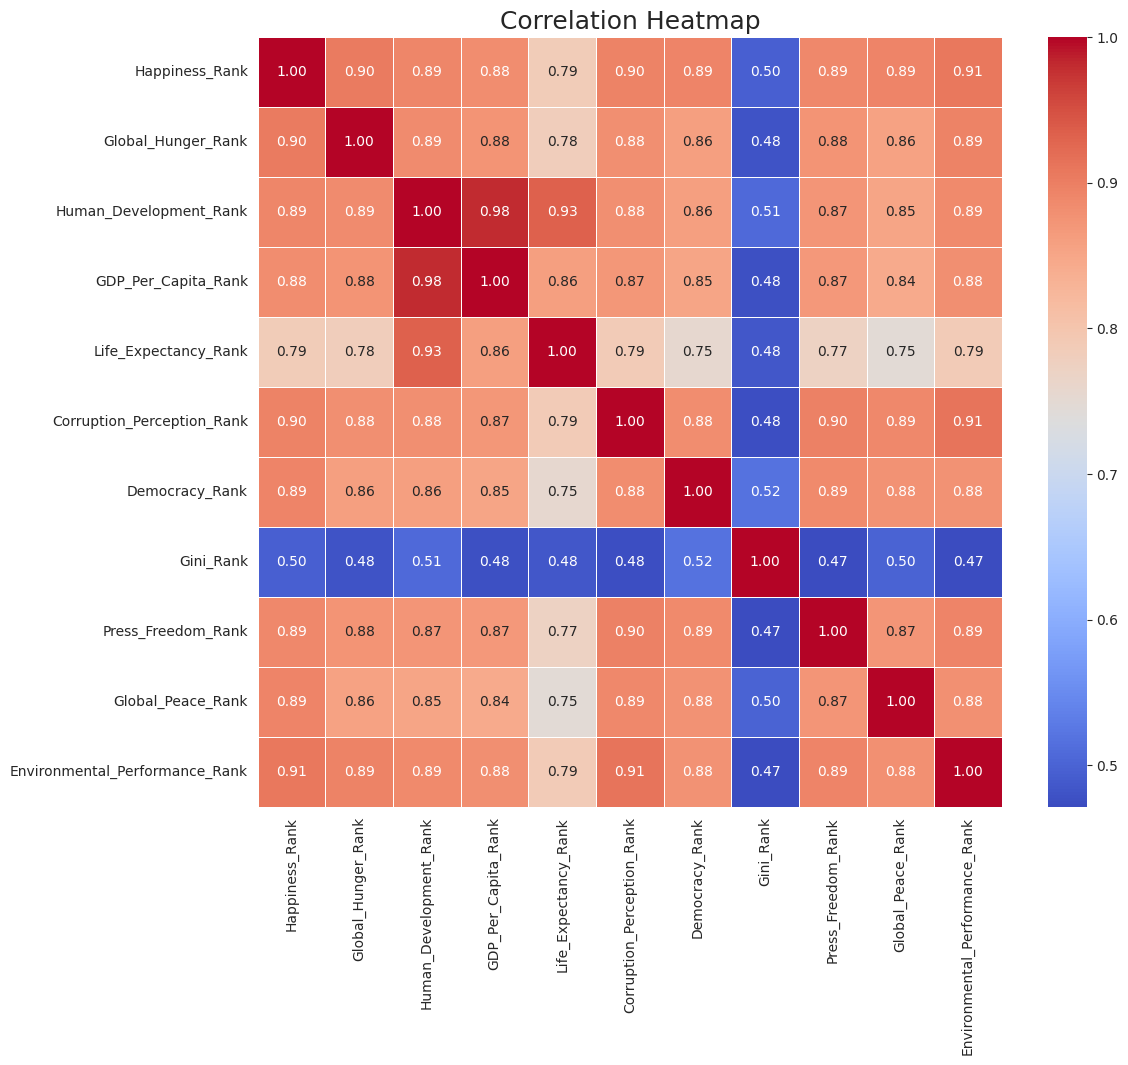

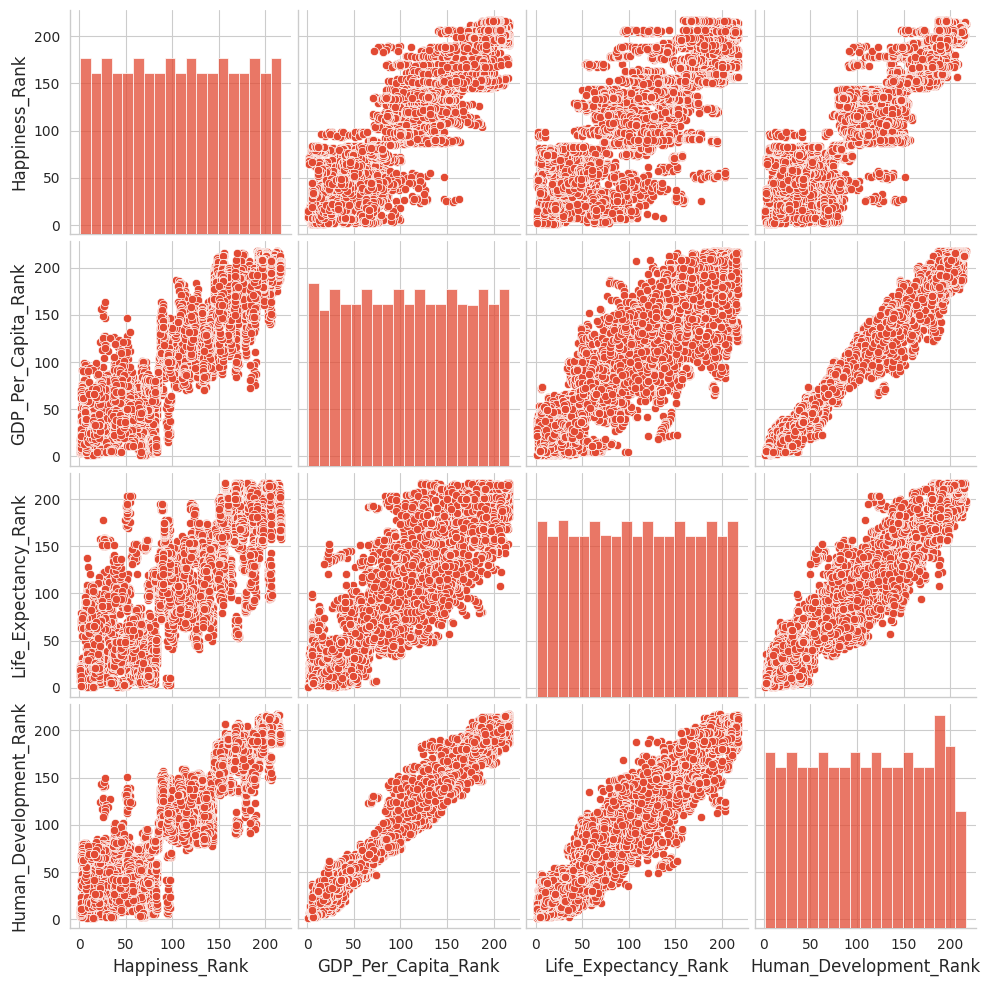

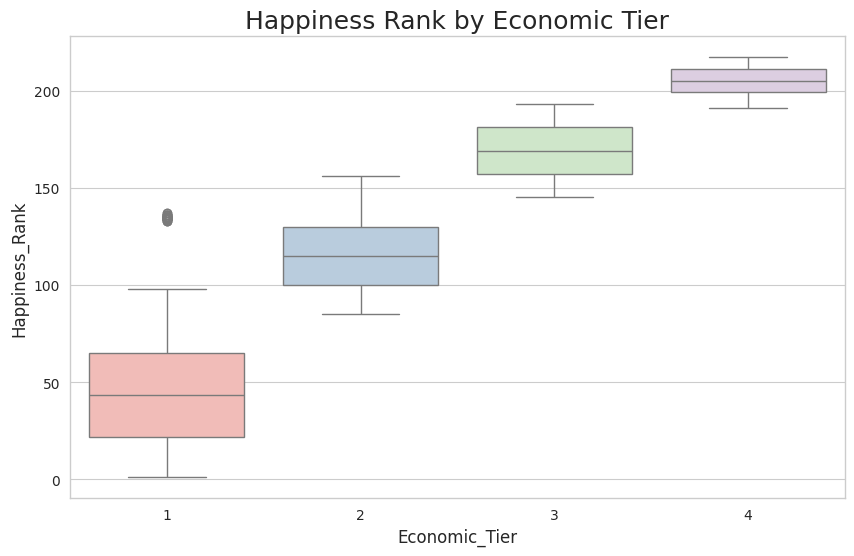

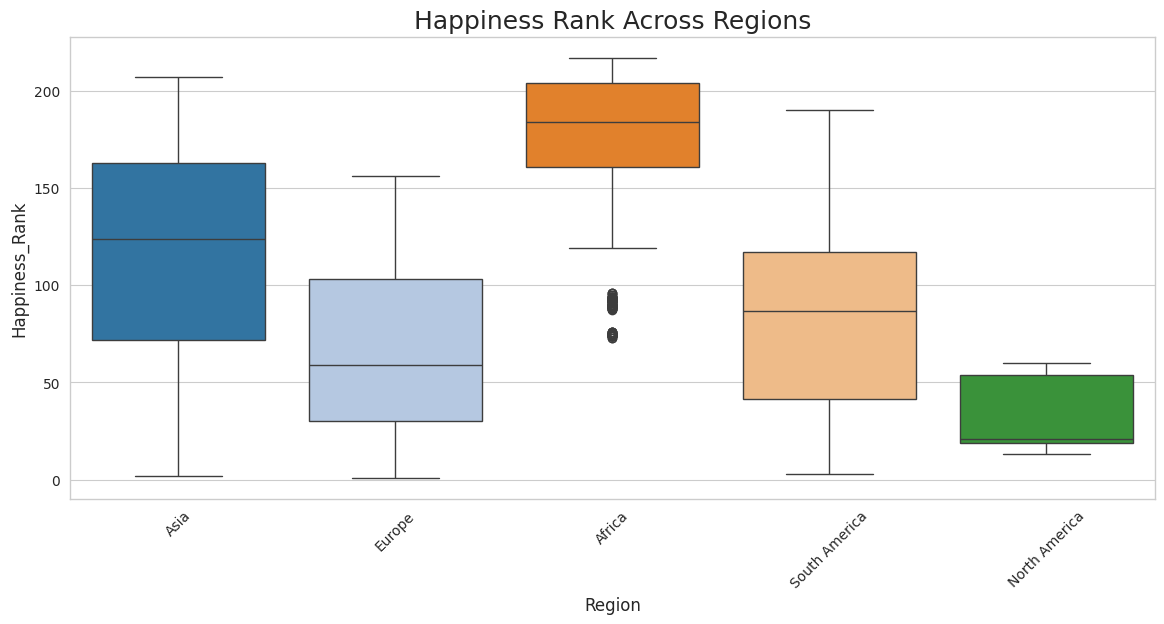

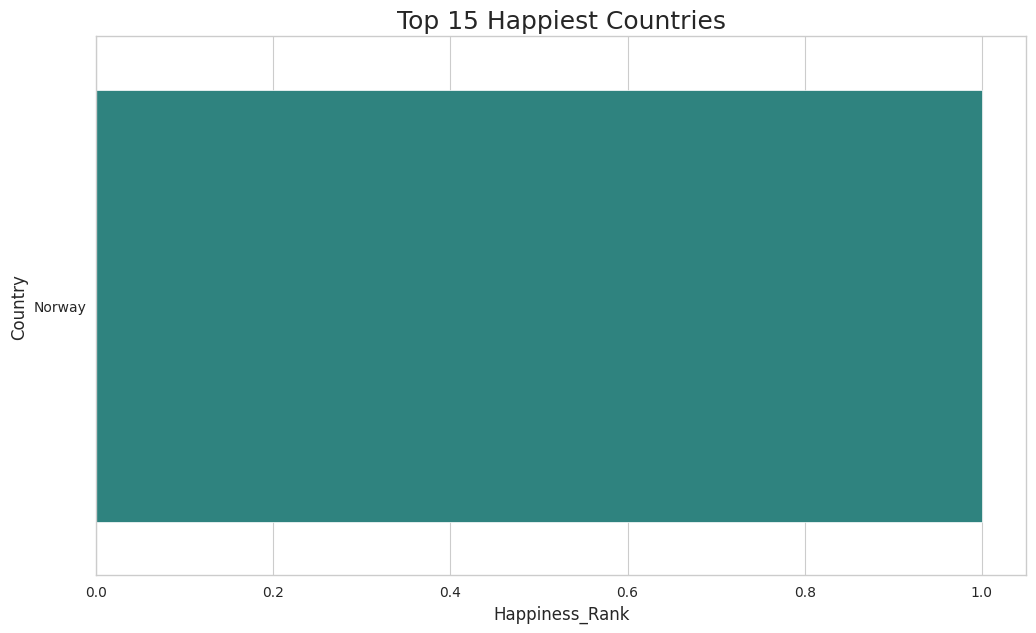

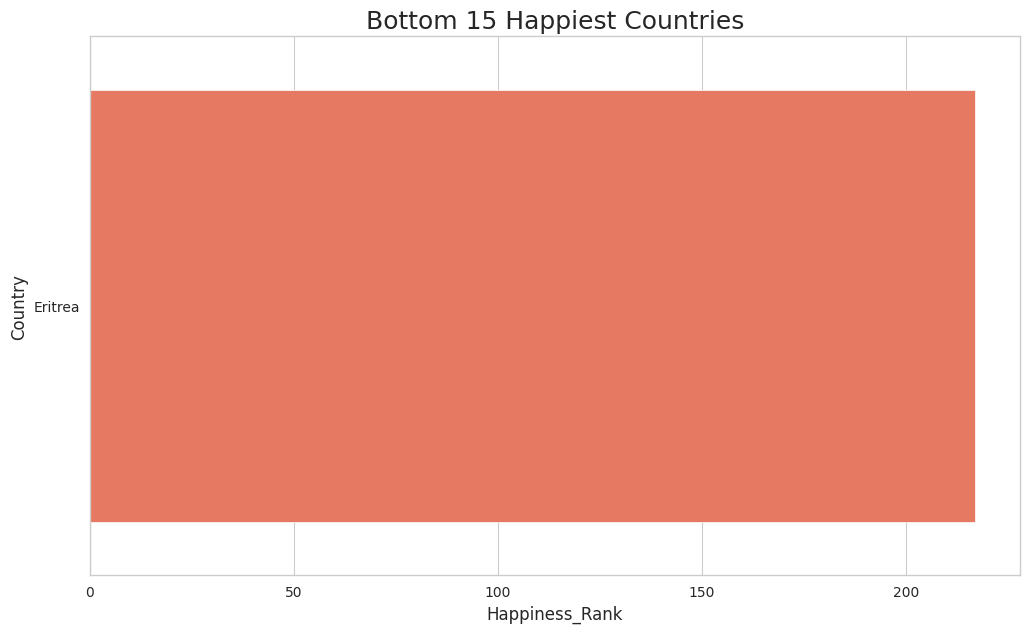

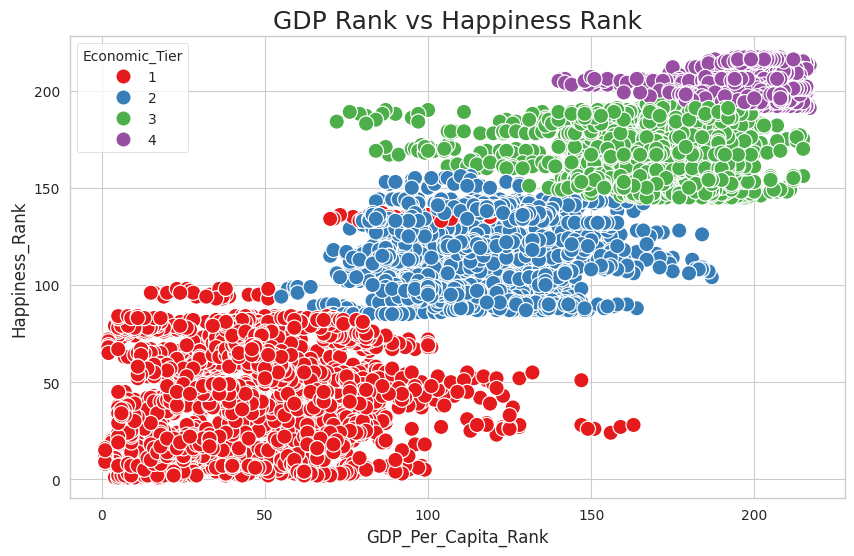

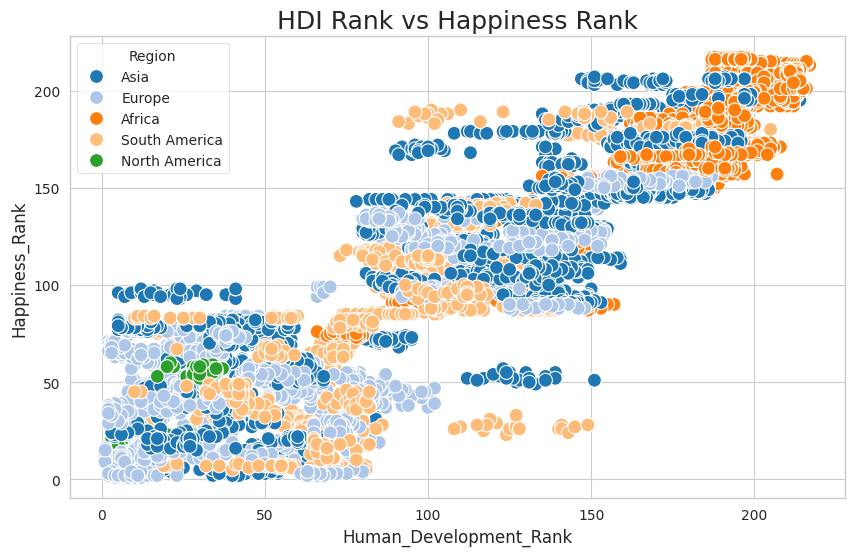

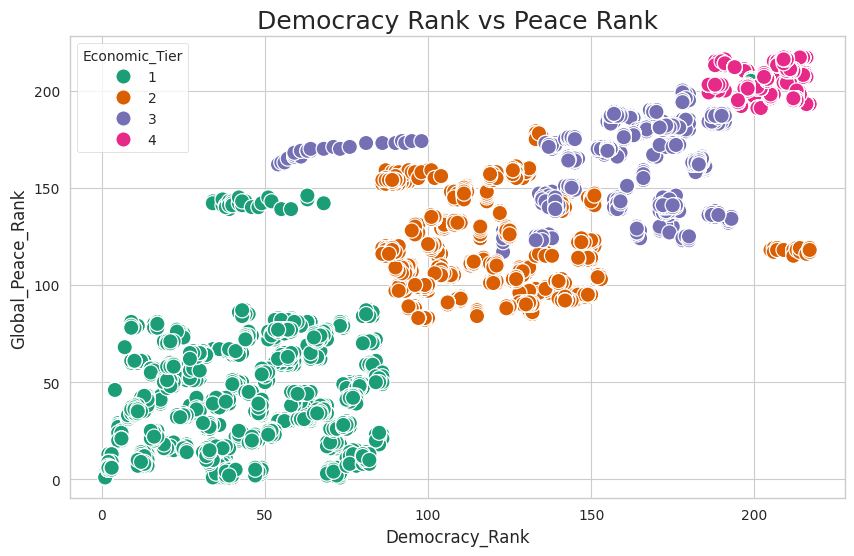

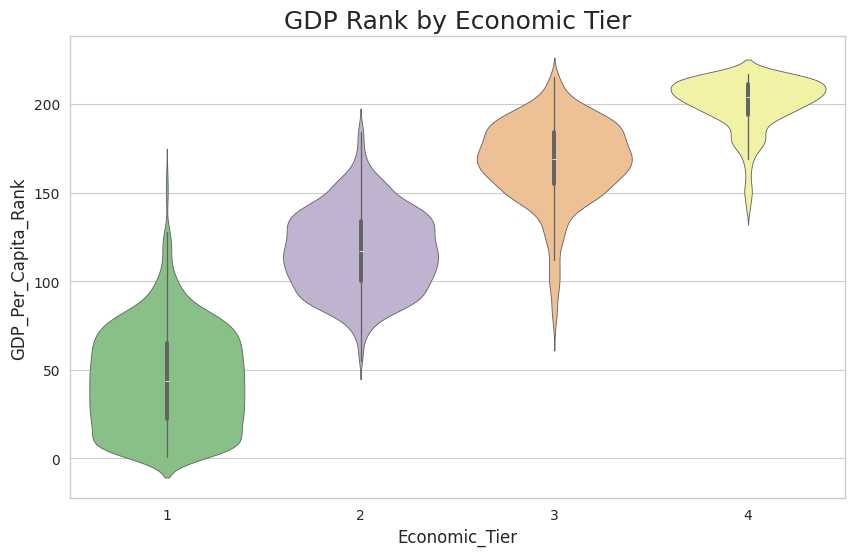

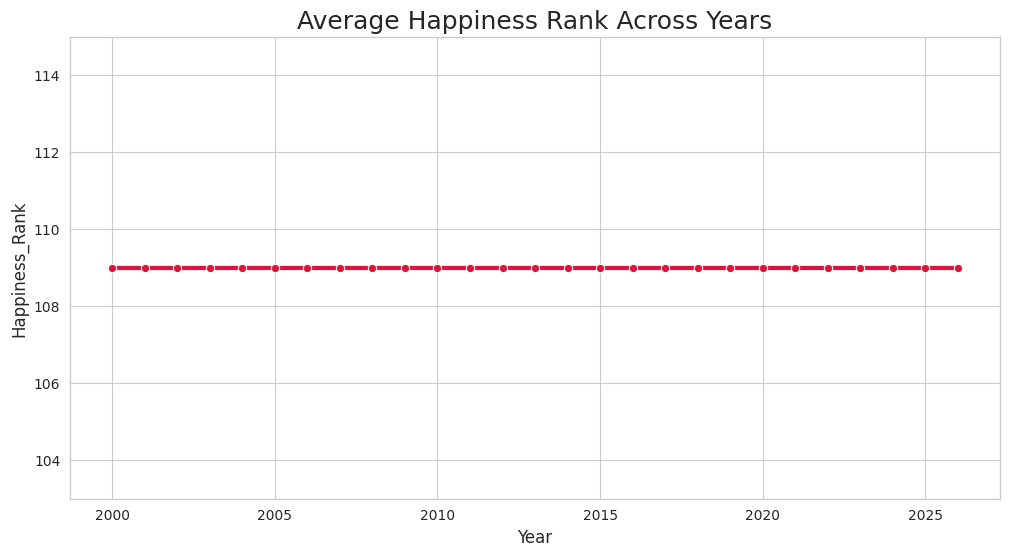

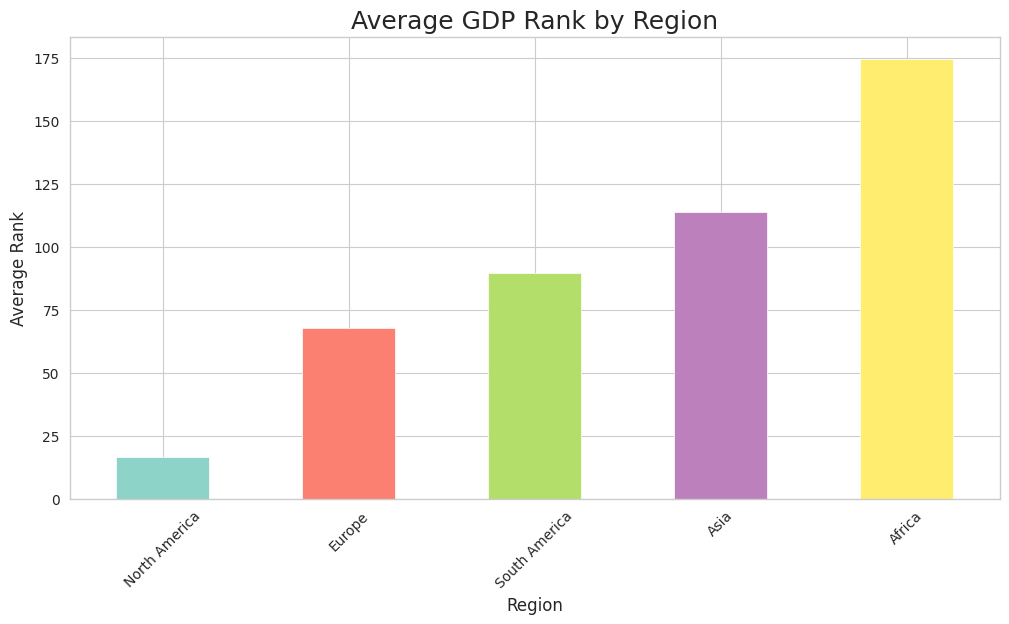

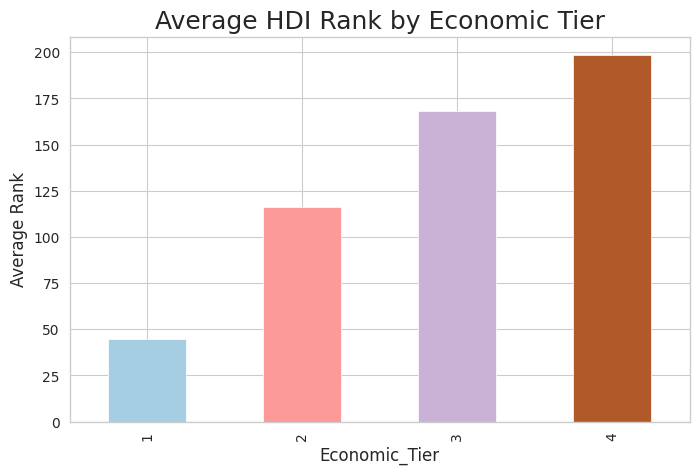

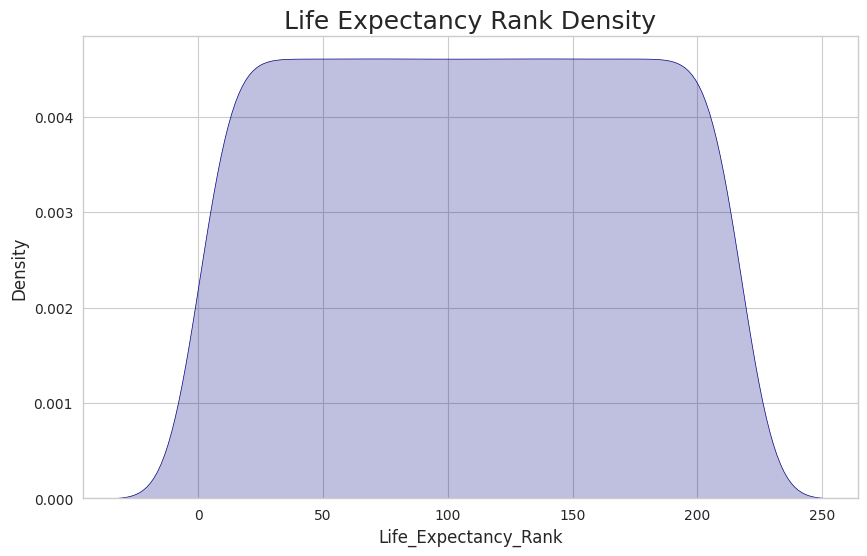

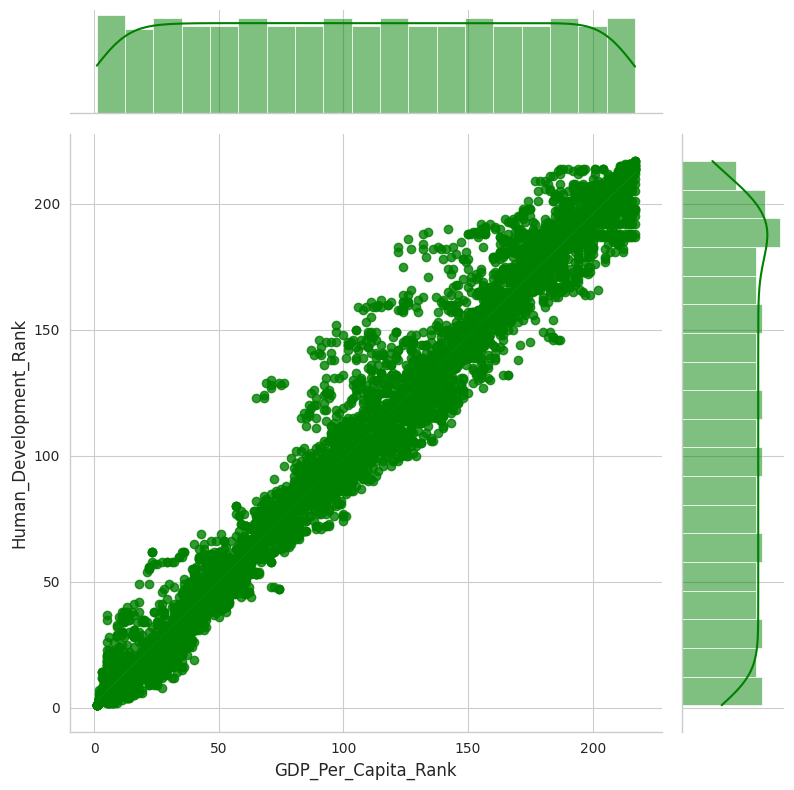

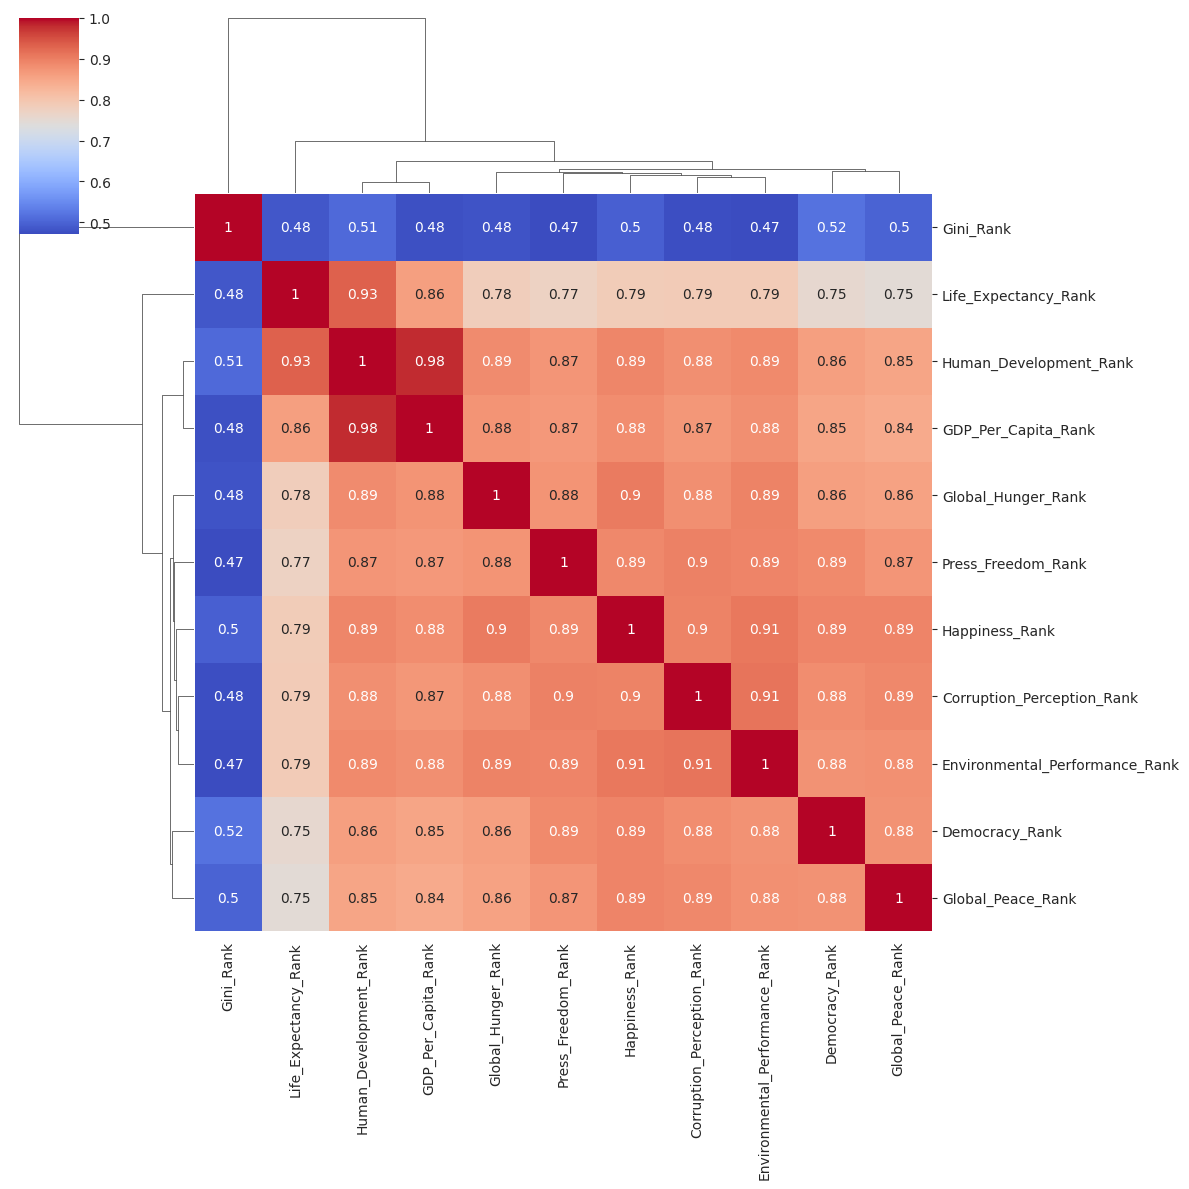

In [11]:
# Plot Style
plt.style.use("ggplot")
sns.set_style("whitegrid")

# ============================================================
# 1. Dataset Information
# ============================================================

print(df.head())
print(df.info())
print(df.describe(include="all"))

# ============================================================
# 2. Missing Values Heatmap
# ============================================================

plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cmap="viridis",
            cbar=False)
plt.title("Missing Values Heatmap",fontsize=18,color="darkblue")
plt.show()

# ============================================================
# 3. Region Count
# ============================================================

plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y="Region",
              palette="Set2",
              order=df["Region"].value_counts().index)

plt.title("Countries by Region",fontsize=18,color="darkred")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()

# ============================================================
# 4. Economic Tier Distribution
# ============================================================

plt.figure(figsize=(8,6))

colors=["gold","skyblue","lightgreen","tomato"]

df["Economic_Tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=[0.03]*len(df["Economic_Tier"].unique())
)

plt.title("Economic Tier Distribution",fontsize=18)
plt.ylabel("")
plt.show()

# ============================================================
# 5. Countries Per Year
# ============================================================

plt.figure(figsize=(12,5))
sns.countplot(data=df,
              x="Year",
              palette="Spectral")

plt.title("Records Per Year",fontsize=18,color="darkgreen")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 6. Happiness Rank Distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.histplot(df["Happiness_Rank"],
             bins=25,
             kde=True,
             color="royalblue")

plt.title("Distribution of Happiness Rank",fontsize=18)
plt.show()

# ============================================================
# 7. GDP Per Capita Rank Distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.histplot(df["GDP_Per_Capita_Rank"],
             bins=25,
             kde=True,
             color="darkorange")

plt.title("GDP Per Capita Rank Distribution",fontsize=18)
plt.show()

# ============================================================
# 8. Life Expectancy Rank Distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.histplot(df["Life_Expectancy_Rank"],
             bins=25,
             kde=True,
             color="purple")

plt.title("Life Expectancy Rank Distribution",fontsize=18)
plt.show()

# ============================================================
# 9. Boxplots of Numerical Features
# ============================================================

num_cols=[
'Happiness_Rank',
'Global_Hunger_Rank',
'Human_Development_Rank',
'GDP_Per_Capita_Rank',
'Life_Expectancy_Rank',
'Corruption_Perception_Rank',
'Democracy_Rank',
'Gini_Rank',
'Press_Freedom_Rank',
'Global_Peace_Rank',
'Environmental_Performance_Rank'
]

plt.figure(figsize=(16,8))

sns.boxplot(data=df[num_cols],
            palette="Set3")

plt.xticks(rotation=75)
plt.title("Boxplots of Numerical Features",fontsize=18)
plt.show()

# ============================================================
# 10. Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,10))

corr=df[num_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=.5,
            fmt=".2f")

plt.title("Correlation Heatmap",fontsize=18)
plt.show()

# ============================================================
# 11. Pairplot
# ============================================================

pair_columns=[
'Happiness_Rank',
'GDP_Per_Capita_Rank',
'Life_Expectancy_Rank',
'Human_Development_Rank'
]

sns.pairplot(df[pair_columns],
             palette="Set2")

plt.show()

# ============================================================
# 12. Happiness Rank by Economic Tier
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x="Economic_Tier",
            y="Happiness_Rank",
            palette="Pastel1")

plt.title("Happiness Rank by Economic Tier",fontsize=18)
plt.show()

# ============================================================
# 13. Happiness Rank by Region
# ============================================================

plt.figure(figsize=(14,6))

sns.boxplot(data=df,
            x="Region",
            y="Happiness_Rank",
            palette="tab20")

plt.xticks(rotation=45)
plt.title("Happiness Rank Across Regions",fontsize=18)
plt.show()

# ============================================================
# 14. Top 15 Happiest Countries
# ============================================================

top15=df.sort_values("Happiness_Rank").head(15)

plt.figure(figsize=(12,7))

sns.barplot(data=top15,
            y="Country",
            x="Happiness_Rank",
            palette="viridis")

plt.title("Top 15 Happiest Countries",fontsize=18)
plt.show()

# ============================================================
# 15. Bottom 15 Happiest Countries
# ============================================================

bottom15=df.sort_values("Happiness_Rank",
                        ascending=False).head(15)

plt.figure(figsize=(12,7))

sns.barplot(data=bottom15,
            y="Country",
            x="Happiness_Rank",
            palette="Reds_r")

plt.title("Bottom 15 Happiest Countries",fontsize=18)
plt.show()

# ============================================================
# 16. Scatter Plot
# GDP Rank vs Happiness Rank
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="GDP_Per_Capita_Rank",
                y="Happiness_Rank",
                hue="Economic_Tier",
                palette="Set1",
                s=120)

plt.title("GDP Rank vs Happiness Rank",fontsize=18)
plt.show()

# ============================================================
# 17. Scatter Plot
# HDI Rank vs Happiness Rank
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="Human_Development_Rank",
                y="Happiness_Rank",
                hue="Region",
                palette="tab20",
                s=100)

plt.title("HDI Rank vs Happiness Rank",fontsize=18)
plt.show()

# ============================================================
# 18. Scatter Plot
# Democracy Rank vs Peace Rank
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="Democracy_Rank",
                y="Global_Peace_Rank",
                hue="Economic_Tier",
                palette="Dark2",
                s=120)

plt.title("Democracy Rank vs Peace Rank",fontsize=18)
plt.show()

# ============================================================
# 19. Violin Plot
# ============================================================

plt.figure(figsize=(10,6))

sns.violinplot(data=df,
               x="Economic_Tier",
               y="GDP_Per_Capita_Rank",
               palette="Accent")

plt.title("GDP Rank by Economic Tier",fontsize=18)
plt.show()

# ============================================================
# 20. Line Plot
# Average Happiness Rank Over Years
# ============================================================

avg=df.groupby("Year")["Happiness_Rank"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(data=avg,
             x="Year",
             y="Happiness_Rank",
             marker="o",
             color="crimson",
             linewidth=3)

plt.title("Average Happiness Rank Across Years",fontsize=18)
plt.grid(True)
plt.show()

# ============================================================
# 21. Average GDP Rank by Region
# ============================================================

region=df.groupby("Region")["GDP_Per_Capita_Rank"].mean().sort_values()

plt.figure(figsize=(12,6))

region.plot(kind="bar",
            color=plt.cm.Set3(np.linspace(0,1,len(region))))

plt.title("Average GDP Rank by Region",fontsize=18)
plt.ylabel("Average Rank")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 22. Average HDI Rank by Economic Tier
# ============================================================

tier=df.groupby("Economic_Tier")["Human_Development_Rank"].mean()

plt.figure(figsize=(8,5))

tier.plot(kind="bar",
          color=plt.cm.Paired(np.linspace(0,1,len(tier))))

plt.title("Average HDI Rank by Economic Tier",fontsize=18)
plt.ylabel("Average Rank")
plt.show()

# ============================================================
# 23. KDE Plot
# ============================================================

plt.figure(figsize=(10,6))

sns.kdeplot(df["Life_Expectancy_Rank"],
            shade=True,
            color="navy")

plt.title("Life Expectancy Rank Density",fontsize=18)
plt.show()

# ============================================================
# 24. Joint Plot
# ============================================================

sns.jointplot(data=df,
              x="GDP_Per_Capita_Rank",
              y="Human_Development_Rank",
              kind="reg",
              color="green",
              height=8)

plt.show()

# ============================================================
# 25. Clustermap
# ============================================================

sns.clustermap(df[num_cols].corr(),
               cmap="coolwarm",
               figsize=(12,12),
               annot=True)

plt.show()


## Feature engineering

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target variable
target = 'Happiness_Rank'
feature_columns = [
    'Year', 
    'Economic_Tier',
    'Global_Hunger_Rank',
    'Human_Development_Rank',
    'GDP_Per_Capita_Rank',
    'Life_Expectancy_Rank',
    'Corruption_Perception_Rank',
    'Democracy_Rank',
    'Gini_Rank',
    'Press_Freedom_Rank',
    'Global_Peace_Rank',
    'Environmental_Performance_Rank'
]

# Filter the data: remove rows with missing values in features or target
model_df = df.dropna(subset=feature_columns + [target]).copy()

# Prepare the input features (X) and target output (y)
X = model_df[feature_columns]
y = model_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print('Linear Regression Model Performance:')
print(f'R-squared: {r2:.3f}')
print(f'Mean Squared Error: {mse:.3f}')

Linear Regression Model Performance:
R-squared: 0.906
Mean Squared Error: 364.597


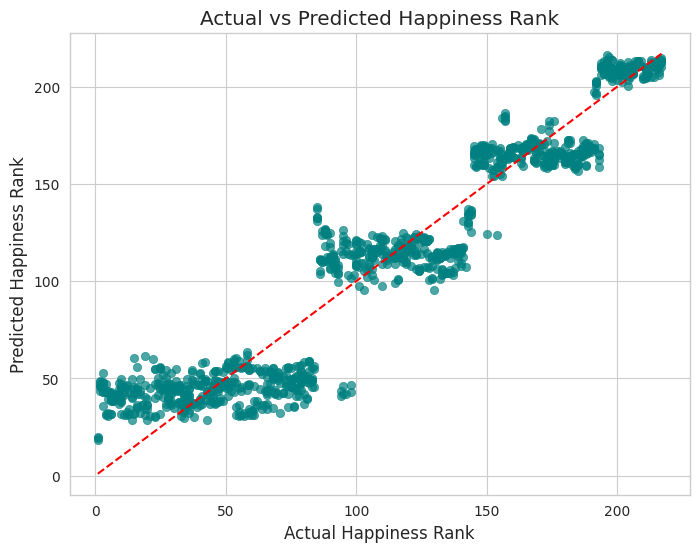

In [13]:
# Plot a scatter plot of predicted vs. actual Happiness_Rank values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.xlabel('Actual Happiness Rank')
plt.ylabel('Predicted Happiness Rank')
plt.title('Actual vs Predicted Happiness Rank')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.show()

## Thank you...pls upovte!!!!!!!!!!!